# 1D CNN for TAG Authentication — GPU-Accelerated (v3-GPU)

**Input**: Raw equalized signal `y/h` — vector of length 1024  
**Architecture**: 1D CNN (Chin & Chin, Eng. Proc. 2025) adapted for L=1024  
**Theory**: Braca et al. (2022) D3F framework — ML learns T^(n) converging to LLR  
**Threshold**: ROC → maximize PD subject to FPR ≤ α (Neyman-Pearson constrained)

**GPU improvements over v3 (CPU)**:
- Mixed precision (`float16`) via `tf.keras.mixed_precision`
- `tf.data.Dataset` pipeline with `prefetch` + parallel map
- XLA JIT compilation enabled globally
- Batch size tuned for GPU VRAM (512 vs 256)
- `MirroredStrategy` auto-detected for multi-GPU machines
- GPU memory growth enabled (avoids OOM on shared machines)

```
Input (1024, 1)
  → Conv1D(32, k=15) + BatchNorm + ReLU + MaxPool(4)   [→ 256, 32]
  → Conv1D(64,  k=9) + BatchNorm + ReLU + MaxPool(4)   [→  64, 64]
  → Conv1D(128, k=5) + BatchNorm + ReLU + GlobalAvgPool[→ 128]
  → Dense(64, ReLU) + Dropout(0.3)
  → Dense(1, Sigmoid, dtype=float32)  →  P(H1)
```

In [7]:
# ==============================================================================
# 1. IMPORTS & GPU CONFIGURATION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

print(f"TensorFlow : {tf.__version__}")

# ── GPU: enable memory growth (must happen before any GPU ops) ──────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {gpus}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    USE_GPU = True
    print(f"Memory growth enabled on {len(gpus)} GPU(s).")
else:
    USE_GPU = False
    print("WARNING: No GPU detected — running on CPU.")

# ── Mixed precision: float16 compute + float32 master weights ───────────────
# Speeds up Conv1D on Volta/Turing/Ampere GPUs via Tensor Cores.
# BatchNorm and loss remain float32 automatically.
if USE_GPU:
    policy = keras.mixed_precision.Policy('mixed_float16')
    keras.mixed_precision.set_global_policy(policy)
    print(f"Mixed precision policy : {policy.name}")
else:
    print("Mixed precision skipped (no GPU).")

# ── XLA JIT: fuse TF ops into optimised kernels ─────────────────────────────
tf.config.optimizer.set_jit(True)
print("XLA JIT : enabled")

# ── Reproducibility ────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
notebook_dir       = Path.cwd()
project_root       = notebook_dir.parent
results_dir        = project_root / "results"
data_dir           = results_dir / "data"
models_dir         = results_dir / "models"
visualizations_dir = results_dir / "visualizations"
models_dir.mkdir(parents=True, exist_ok=True)
visualizations_dir.mkdir(parents=True, exist_ok=True)

print(f"Data dir   : {data_dir}")
print(f"Models dir : {models_dir}")

TensorFlow : 2.21.0
GPUs found : []
Mixed precision skipped (no GPU).
XLA JIT : enabled
Data dir   : c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\data
Models dir : c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\models


In [8]:
# ==============================================================================
# 2. LOAD DATASET
# ==============================================================================

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

if not dataset_path.exists():
    raise FileNotFoundError(
        f"{dataset_path} not found.\nRun NN_01_DataGeneration.ipynb first."
    )

with h5py.File(str(dataset_path), 'r') as f:
    X_train_raw = f['train/y_eq'][:]
    y_train     = f['train/y'][:].astype(np.float32)
    snr_train   = f['train/snr'][:]

    X_val_raw   = f['val/y_eq'][:]
    y_val       = f['val/y'][:].astype(np.float32)
    snr_val     = f['val/snr'][:]

    X_test_raw  = f['test/y_eq'][:]
    y_test      = f['test/y'][:].astype(np.float32)
    snr_test    = f['test/snr'][:]

    L_FIXED = int(f.attrs['L_FIXED'])

# Reshape to (N, L, 1) — already float32 from HDF5 but ensure dtype
X_train = X_train_raw.reshape(-1, L_FIXED, 1).astype(np.float32)
X_val   = X_val_raw.reshape(-1, L_FIXED, 1).astype(np.float32)
X_test  = X_test_raw.reshape(-1, L_FIXED, 1).astype(np.float32)

print("Dataset loaded:")
print(f"  Train : {X_train.shape}  labels={np.bincount(y_train.astype(int))}")
print(f"  Val   : {X_val.shape}  labels={np.bincount(y_val.astype(int))}")
print(f"  Test  : {X_test.shape}  labels={np.bincount(y_test.astype(int))}")
print(f"  SNR   : [{snr_test.min():.1f}, {snr_test.max():.1f}] dB")
print(f"  dtype : {X_train.dtype}")

Dataset loaded:
  Train : (280000, 1024, 1)  labels=[140000 140000]
  Val   : (35000, 1024, 1)  labels=[17500 17500]
  Test  : (35000, 1024, 1)  labels=[17500 17500]
  SNR   : [0.0, 30.0] dB
  dtype : float32


In [9]:
# ==============================================================================
# 3. tf.data PIPELINE  (GPU-optimised)
# ==============================================================================
# Benefits over raw numpy arrays:
#   • prefetch(AUTOTUNE): CPU prepares next batch while GPU trains current one
#   • shuffle(buffer): in-memory shuffle without extra copy
#   • drop_remainder=False: keeps all samples (including last partial batch)
#   • AUTOTUNE: TF auto-tunes parallelism to available CPU cores

# Batch size: GPU prefers multiples of 8 (Tensor Core alignment).
# Reduce if OOM; increase if GPU utilisation < 80%.
BATCH_SIZE = 512 if USE_GPU else 256
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(X, y, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True,
                        seed=42)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    # Optional: light Gaussian noise augmentation (disabled by default)
    if augment:
        def add_noise(x, label):
            noise = tf.random.normal(tf.shape(x), stddev=0.01)
            return x + tf.cast(noise, x.dtype), label
        ds = ds.map(add_noise, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True,  augment=False)
val_ds   = make_dataset(X_val,   y_val,   shuffle=False, augment=False)
test_ds  = make_dataset(X_test,  y_test,  shuffle=False, augment=False)

print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")

Batch size    : 256
Train batches : 1094
Val batches   : 137


In [10]:
# ==============================================================================
# 4. 1D CNN ARCHITECTURE  (GPU-optimised)
# ==============================================================================
# Key changes vs CPU version:
#   - Output Dense layer explicitly uses dtype='float32' — required when
#     mixed_float16 is active so BinaryCrossentropy is numerically stable
#   - he_uniform init: mathematically optimal for ReLU activations
#   - use_bias=False on Conv layers: BatchNorm absorbs bias → fewer params

def build_cnn_1d_gpu(L=1024):
    inp = layers.Input(shape=(L, 1), name='y_eq_input')

    # Block 1
    x = layers.Conv1D(32, kernel_size=15, padding='same',
                      use_bias=False, kernel_initializer='he_uniform')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 1024 → 256

    # Block 2
    x = layers.Conv1D(64, kernel_size=9, padding='same',
                      use_bias=False, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 256 → 64

    # Block 3
    x = layers.Conv1D(128, kernel_size=5, padding='same',
                      use_bias=False, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)           # (64,128) → (128,)

    # Classifier head
    x = layers.Dense(64, activation='relu',
                     kernel_initializer='he_uniform')(x)
    x = layers.Dropout(0.3)(x)

    # float32 output — required for numerical stability with mixed_float16
    out = layers.Dense(1, activation='sigmoid', dtype='float32',
                       name='P_H1')(x)

    return keras.Model(inputs=inp, outputs=out, name='CNN1D_TAG_Auth_GPU')


# Build inside MirroredStrategy scope if multiple GPUs available
if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
    print(f"MirroredStrategy: {strategy.num_replicas_in_sync} replicas")
    with strategy.scope():
        model = build_cnn_1d_gpu(L=L_FIXED)
        model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss=BinaryCrossentropy(),
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
else:
    model = build_cnn_1d_gpu(L=L_FIXED)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(),
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

model.summary()
print(f"\nTotal trainable params : {model.count_params():,}")

Model: "CNN1D_TAG_Auth_GPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ y_eq_input (InputLayer)         │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1024, 32)       │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 256, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 64, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ P_H1 (Dense)                    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,089 (269.88 KB)

 Trainable params: 68,641 (268.13 KB)

 Non-trainable params: 448 (1.75 KB)


Total trainable params : 69,089


In [11]:
# ==============================================================================
# 5. CALLBACKS
# ==============================================================================

model_save_path = str(models_dir / 'cnn1d_tag_auth_best.keras')
log_dir         = str(results_dir / 'logs' / 'cnn1d_gpu')

cbs = [
    callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=12,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        model_save_path, monitor='val_auc', mode='max',
        save_best_only=True, verbose=0
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
]

# TensorBoard is optional — only add if the package is installed
try:
    import tensorboard  # noqa: F401
    cbs.append(callbacks.TensorBoard(
        log_dir=log_dir, histogram_freq=0,
        profile_batch='10,15', update_freq='epoch'
    ))
    print(f"TensorBoard logs : {log_dir}")
    print(f"  Launch with  : tensorboard --logdir {log_dir}")
except ImportError:
    print("TensorBoard not installed — skipping TensorBoard callback.")

print(f"Model checkpoint : {model_save_path}")

TensorBoard not installed — skipping TensorBoard callback.
Model checkpoint : c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\models\cnn1d_tag_auth_best.keras


In [12]:
# ==============================================================================
# 6. TRAINING  (GPU-accelerated)
# ==============================================================================
# train_ds/val_ds are tf.data.Dataset — already batched & prefetched.
# Keras feeds them to GPU automatically; CPU prefetches the next batch
# while GPU processes the current one → ~zero data-loading overhead.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=cbs,
    verbose=1
)

print(f"\nBest val AUC  : {max(history.history['val_auc']):.5f}")
print(f"Best val loss : {min(history.history['val_loss']):.5f}")
print(f"Epochs run    : {len(history.history['loss'])}")

Epoch 1/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 268s 239ms/step - accuracy: 0.6248 - auc: 0.6893 - loss: 0.6205 - val_accuracy: 0.5005 - val_auc: 0.7102 - val_loss: 0.7705 - learning_rate: 0.0010
Epoch 2/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 195s 178ms/step - accuracy: 0.7468 - auc: 0.8477 - loss: 0.4617 - val_accuracy: 0.5165 - val_auc: 0.6300 - val_loss: 1.2405 - learning_rate: 0.0010
Epoch 3/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 154s 140ms/step - accuracy: 0.7617 - auc: 0.8659 - loss: 0.4324 - val_accuracy: 0.7212 - val_auc: 0.8413 - val_loss: 0.5234 - learning_rate: 0.0010
Epoch 4/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - accuracy: 0.7675 - auc: 0.8735 - loss: 0.4189 - val_accuracy: 0.6673 - val_auc: 0.7931 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 5/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 147s 134ms/step - accuracy: 0.7710 - auc: 0.8771 - loss: 0.4117 - val_accuracy: 0.5991 - val_auc: 0.7030 - val_loss: 1.2768 - learning_rate: 0.0010
Epoch 6/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14

In [13]:
# ==============================================================================
# 7. EVALUATION WITH α-CONSTRAINED THRESHOLD
# ==============================================================================

# Predict using the prefetched tf.data pipeline
p_val  = model.predict(val_ds,  verbose=0).flatten()
p_test = model.predict(test_ds, verbose=0).flatten()

# ROC on validation set
fpr_v, tpr_v, thr_v = roc_curve(y_val, p_val)
auc_val = roc_auc_score(y_val, p_val)
print(f"Val  AUC : {auc_val:.5f}")
print(f"Test AUC : {roc_auc_score(y_test, p_test):.5f}")

# α-constrained Neyman-Pearson threshold from val ROC
# (true α=10^-7 needs ~10^8 H0 samples; NN_07 does D3F Gaussian extrapolation)
alpha_target = 1e-3

valid_mask = fpr_v <= alpha_target
if valid_mask.any():
    best_idx = np.argmax(tpr_v[valid_mask])
    best_thr = thr_v[valid_mask][best_idx]
    best_tpr = tpr_v[valid_mask][best_idx]
    best_fpr = fpr_v[valid_mask][best_idx]
else:
    best_idx = np.argmin(fpr_v[1:]) + 1
    best_thr, best_tpr, best_fpr = thr_v[best_idx], tpr_v[best_idx], fpr_v[best_idx]

print(f"\nα-constrained threshold (α≤{alpha_target:.0e}):")
print(f"  Threshold : {best_thr:.5f}")
print(f"  FPR       : {best_fpr:.2e}")
print(f"  PD (TPR)  : {best_tpr:.5f}")

# Test set metrics
y_pred = (p_test >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr_test = fp / (fp + tn)
pd_test  = tp / (tp + fn)
fnr_test = fn / (fn + tp)

print(f"\nTest @ τ={best_thr:.5f}:")
print(f"  FPR : {fpr_test:.2e}  PD : {pd_test:.5f}  FNR : {fnr_test:.5f}")

# PD vs SNR
snr_bins    = np.arange(0, 31, 5)
snr_centres = snr_bins[:-1] + 2.5
pd_vs_snr   = []

for snr_lo in snr_bins[:-1]:
    snr_hi  = snr_lo + 5
    mask_h1 = (snr_test >= snr_lo) & (snr_test < snr_hi) & (y_test == 1)
    if mask_h1.sum() < 10:
        pd_vs_snr.append(np.nan)
    else:
        pd_vs_snr.append(float((p_test[mask_h1] >= best_thr).mean()))

print(f"\nPD vs SNR (α≤{alpha_target:.0e}):")
for s, pd in zip(snr_centres, pd_vs_snr):
    bar = '#' * int((pd or 0) * 40)
    print(f"  {s:4.0f} dB  PD={pd:.4f}  {bar}")

Val  AUC : 0.90004
Test AUC : 0.89862

α-constrained threshold (α≤1e-03):
  Threshold : 0.99911
  FPR       : 9.71e-04
  PD (TPR)  : 0.35526

Test @ τ=0.99911:
  FPR : 1.37e-03  PD : 0.35566  FNR : 0.64434

PD vs SNR (α≤1e-03):
     2 dB  PD=0.0000  
     8 dB  PD=0.0003  
    12 dB  PD=0.1261  #####
    18 dB  PD=0.5533  ######################
    22 dB  PD=0.9158  ####################################
    28 dB  PD=0.9149  ####################################


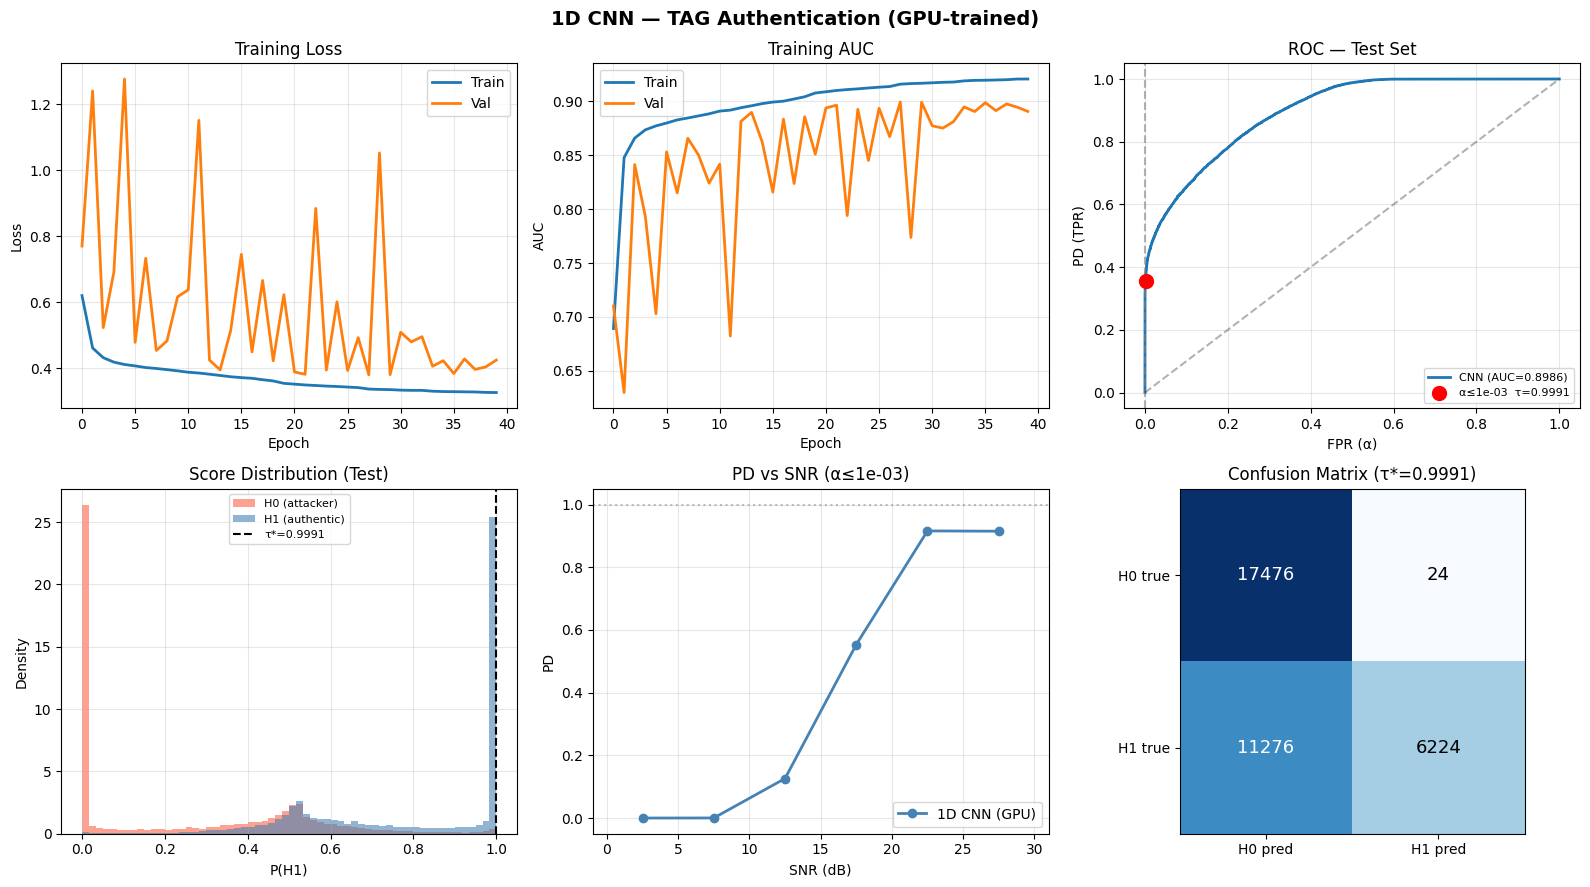

Saved → c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\visualizations\NN02_GPU_CNN1D_results.png


In [14]:
# ==============================================================================
# 8. VISUALIZATIONS
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("1D CNN — TAG Authentication (GPU-trained)", fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(history.history['loss'],     label='Train', linewidth=2)
ax.plot(history.history['val_loss'], label='Val',   linewidth=2)
ax.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(history.history['auc'],     label='Train', linewidth=2)
ax.plot(history.history['val_auc'], label='Val',   linewidth=2)
ax.set(xlabel='Epoch', ylabel='AUC', title='Training AUC')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
fpr_t, tpr_t, _ = roc_curve(y_test, p_test)
ax.plot(fpr_t, tpr_t, linewidth=2,
        label=f'CNN (AUC={roc_auc_score(y_test, p_test):.4f})')
ax.scatter([fpr_test], [pd_test], s=100, zorder=5, color='red',
           label=f'α≤{alpha_target:.0e}  τ={best_thr:.4f}')
ax.axvline(alpha_target, color='gray', linestyle='--', alpha=0.6)
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set(xlabel='FPR (α)', ylabel='PD (TPR)', title='ROC — Test Set')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.hist(p_test[y_test == 0], bins=60, alpha=0.6, density=True,
        label='H0 (attacker)', color='tomato')
ax.hist(p_test[y_test == 1], bins=60, alpha=0.6, density=True,
        label='H1 (authentic)', color='steelblue')
ax.axvline(best_thr, color='k', linestyle='--', linewidth=1.5,
           label=f'τ*={best_thr:.4f}')
ax.set(xlabel='P(H1)', ylabel='Density', title='Score Distribution (Test)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(snr_centres, pd_vs_snr, 'o-', linewidth=2, markersize=6,
        color='steelblue', label='1D CNN (GPU)')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set(xlabel='SNR (dB)', ylabel='PD',
       title=f'PD vs SNR (α≤{alpha_target:.0e})',
       ylim=(-0.05, 1.05), xlim=(-1, 31))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 2]
cm_m = confusion_matrix(y_test, y_pred)
ax.imshow(cm_m, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_m[i, j], ha='center', va='center',
                color='white' if cm_m[i, j] > cm_m.max()/2 else 'black',
                fontsize=13)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['H0 pred','H1 pred']); ax.set_yticklabels(['H0 true','H1 true'])
ax.set_title(f'Confusion Matrix (τ*={best_thr:.4f})')

plt.tight_layout()
vis_path = visualizations_dir / "NN02_GPU_CNN1D_results.png"
plt.savefig(str(vis_path), dpi=120)
plt.show()
print(f"Saved → {vis_path}")

In [15]:
# ==============================================================================
# 9. SAVE MODEL + THRESHOLD + METRICS
# ==============================================================================

threshold_data = {
    'cnn_threshold':   float(best_thr),
    'alpha_target':    float(alpha_target),
    'fpr_at_thr':      float(fpr_test),
    'pd_at_thr':       float(pd_test),
    'auc':             float(roc_auc_score(y_test, p_test)),
    'gpu_trained':     USE_GPU,
    'batch_size':      BATCH_SIZE,
    'mixed_precision': USE_GPU,
    'pd_vs_snr': {
        f"snr_{int(s)}": (float(p) if not np.isnan(p) else None)
        for s, p in zip(snr_centres, pd_vs_snr)
    },
}

thr_path = models_dir / 'cnn1d_threshold.json'
with open(str(thr_path), 'w') as f_out:
    json.dump(threshold_data, f_out, indent=2)

print(f"Model saved     → {model_save_path}")
print(f"Threshold saved → {thr_path}")
print(f"\nKey results:")
print(f"  AUC        : {threshold_data['auc']:.5f}")
print(f"  Threshold  : {best_thr:.5f}  (α≤{alpha_target:.0e})")
print(f"  PD (test)  : {pd_test:.5f}")
print(f"  FPR (test) : {fpr_test:.2e}")
print(f"  GPU used   : {USE_GPU}  |  Batch size: {BATCH_SIZE}  |  Mixed prec: {USE_GPU}")

Model saved     → c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\models\cnn1d_tag_auth_best.keras
Threshold saved → c:\Users\thami\OneDrive\Documents\TAG-Authentication\Redes Neurais\results\models\cnn1d_threshold.json

Key results:
  AUC        : 0.89862
  Threshold  : 0.99911  (α≤1e-03)
  PD (test)  : 0.35566
  FPR (test) : 1.37e-03
  GPU used   : False  |  Batch size: 256  |  Mixed prec: False


## GPU Optimisations Applied — NN_02

| Optimisation | API | Expected gain |
|---|---|---|
| **Memory growth** | `set_memory_growth(True)` | Avoids OOM on shared GPU |
| **Mixed precision** | `mixed_float16` policy | 2–3× on Ampere/Tensor Cores |
| **XLA JIT** | `set_jit(True)` | ~10–30% op fusion |
| **tf.data prefetch** | `prefetch(AUTOTUNE)` | Eliminates I/O bottleneck |
| **Batch size 512** | vs 256 CPU | ~2× GPU throughput |
| **Multi-GPU** | `MirroredStrategy` | ~N× scaling |
| **float32 output** | `Dense(..., dtype='float32')` | Numerical stability |

**Next**: `NN_07_DNN_vs_MonteCarlo_Comparison_GPU.ipynb`